#Judul : Prediksi Harga Dogecoin Jangka Pendek Menggunakan Teknik Multi-Step

#Pendahuluan

##Latar Belakang
Dogecoin, yang awalnya diciptakan sebagai meme cryptocurrency, kini telah berkembang menjadi salah satu aset digital yang cukup populer. Dengan komunitas yang besar dan penggunaan yang semakin luas, Dogecoin menarik perhatian banyak investor dan trader yang tertarik dengan potensi pertumbuhannya di pasar cryptocurrency. Keunggulan Dogecoin terletak pada biaya transaksi yang rendah dan waktu transaksi yang cepat, menjadikannya pilihan menarik dibandingkan dengan beberapa cryptocurrency lainnya.

Namun, Dogecoin juga dikenal dengan volatilitas harga yang tinggi, yang dapat dipengaruhi oleh berbagai faktor eksternal, termasuk sentimen pasar, adopsi teknologi blockchain, serta pengaruh dari tokoh publik seperti Elon Musk. Fluktuasi harga yang cepat dan sering kali tidak terduga ini menjadikan prediksi harga Dogecoin jangka pendek sebuah tantangan besar. Oleh karena itu, analisis prediksi harga Dogecoin jangka pendek menggunakan teknik yang tepat sangat penting bagi investor dan trader untuk membuat keputusan yang lebih terinformasi.

Dalam rangka mendukung tujuan investasi dan strategi perdagangan, penggunaan teknik multi-step forecasting menjadi relevan untuk memprediksi harga Dogecoin dalam jangka pendek. Teknik ini memungkinkan prediksi untuk beberapa langkah ke depan, yang dapat memberikan gambaran yang lebih baik mengenai pergerakan harga dalam waktu yang lebih dekat, membantu meminimalkan risiko dan memaksimalkan keuntungan.

##Tujuan
Tujuan dari analisis ini adalah untuk mengembangkan model prediksi harga Dogecoin jangka pendek menggunakan teknik multi-step forecasting. Dengan menggunakan pendekatan ini, diharapkan dapat memberikan proyeksi harga yang lebih akurat untuk periode waktu yang lebih singkat. Model ini bertujuan untuk membantu investor dan trader dalam mengambil keputusan yang lebih terinformasi mengenai pembelian, penjualan, atau alokasi aset Dogecoin dalam portofolio mereka.

##Rumusan Masalah
Bagaimana cara memprediksi harga Dogecoin jangka pendek secara efektif menggunakan teknik multi-step forecasting?
Algoritma apa yang paling cocok untuk prediksi harga Dogecoin jangka pendek dengan pendekatan multi-step?
Seberapa akurat model prediksi harga Dogecoin jangka pendek yang dihasilkan menggunakan teknik multi-step forecasting?


#Metodologi

##Memahami Data


Data yang digunakan dalam analisis ini merupakan data historis harga Dogecoin yang diperoleh dari **Yahoo Finance**. Data tersebut mencakup berbagai variabel penting seperti `Date`, `Price`, `Adj Close`, `Close`, `High`, `Low`, `Open`, dan `Volume`. Kolom-kolom ini memberikan informasi lengkap tentang harga Dogecoin pada setiap hari perdagangan, termasuk harga pembukaan (Open), harga penutupan (Close), harga tertinggi (High), harga terendah (Low), serta volume perdagangan (Volume) yang terjadi. Biasanya, untuk analisis harga, variabel `Close` atau `Adj Close` yang lebih sering digunakan, karena `Adj Close` disesuaikan dengan perubahan corporate actions seperti dividen atau stock splits.

Data historis yang digunakan dalam analisis ini mencakup 1826 entri yang dimulai pada 1 Januari 2019 hingga 31 Desember 2023. Jumlah ini mencerminkan data harian selama lima tahun perdagangan. Meskipun pasar cryptocurrency seperti Dogecoin tidak terikat pada jam perdagangan tertentu (seperti pasar saham), jumlah data ini cukup representatif untuk analisis jangka panjang. Dalam periode ini, harga Dogecoin sering dipengaruhi oleh berbagai faktor eksternal, termasuk sentimen pasar, pergerakan mata uang digital lainnya, dan faktor sosial seperti pengaruh tokoh publik.

Untuk mengunduh data harga Dogecoin dari Yahoo Finance, kita bisa menggunakan library Python seperti `yfinance`, yang memungkinkan kita untuk mengakses dan mengunduh data harga historis secara langsung. Dengan menggunakan kode sederhana, kita dapat mengunduh data dari 2019 hingga 2023 dan mengolahnya untuk analisis lebih lanjut, seperti peramalan harga dengan menggunakan model time series atau machine learning. Dengan demikian, data ini memberikan dasar yang kuat untuk melakukan analisis prediktif terhadap fluktuasi harga Dogecoin di masa depan.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import gdown

# ID file dari URL Google Drive
file_id = '16kXDWFkXFL4Oun0TGNYDsFdV2RlL_yaf'

# Membuat URL unduhan
url = f'https://drive.google.com/uc?id={file_id}'

# Mengunduh file
output = 'dogecoin_data.csv'  # Nama file CSV yang akan disimpan
gdown.download(url, output, quiet=False)

# Menampilkan pesan sukses
print(f"File telah berhasil diunduh sebagai {output}")

Downloading...
From: https://drive.google.com/uc?id=16kXDWFkXFL4Oun0TGNYDsFdV2RlL_yaf
To: /content/dogecoin_data.csv
100%|██████████| 253k/253k [00:00<00:00, 5.67MB/s]

File telah berhasil diunduh sebagai dogecoin_data.csv


In [2]:
import pandas as pd

# Membaca file CSV yang telah diunduh
data = pd.read_csv('dogecoin_data.csv')

# Menampilkan 5 baris pertama dari data
print(data.head())

                        Date     Price  Adj Close     Close      High  \
0  2019-09-01 00:00:00+00:00  0.002492   0.002492  0.002533  0.002443   
1  2019-09-02 00:00:00+00:00  0.002596   0.002596  0.002616  0.002462   
2  2019-09-03 00:00:00+00:00  0.002595   0.002595  0.002724  0.002560   
3  2019-09-04 00:00:00+00:00  0.002690   0.002690  0.002695  0.002541   
4  2019-09-05 00:00:00+00:00  0.002531   0.002531  0.002692  0.002505   

        Low      Open  Volume  
0  0.002512  22742519     NaN  
1  0.002492  25999239     NaN  
2  0.002598  40548612     NaN  
3  0.002596  27623103     NaN  
4  0.002690  32285101     NaN  


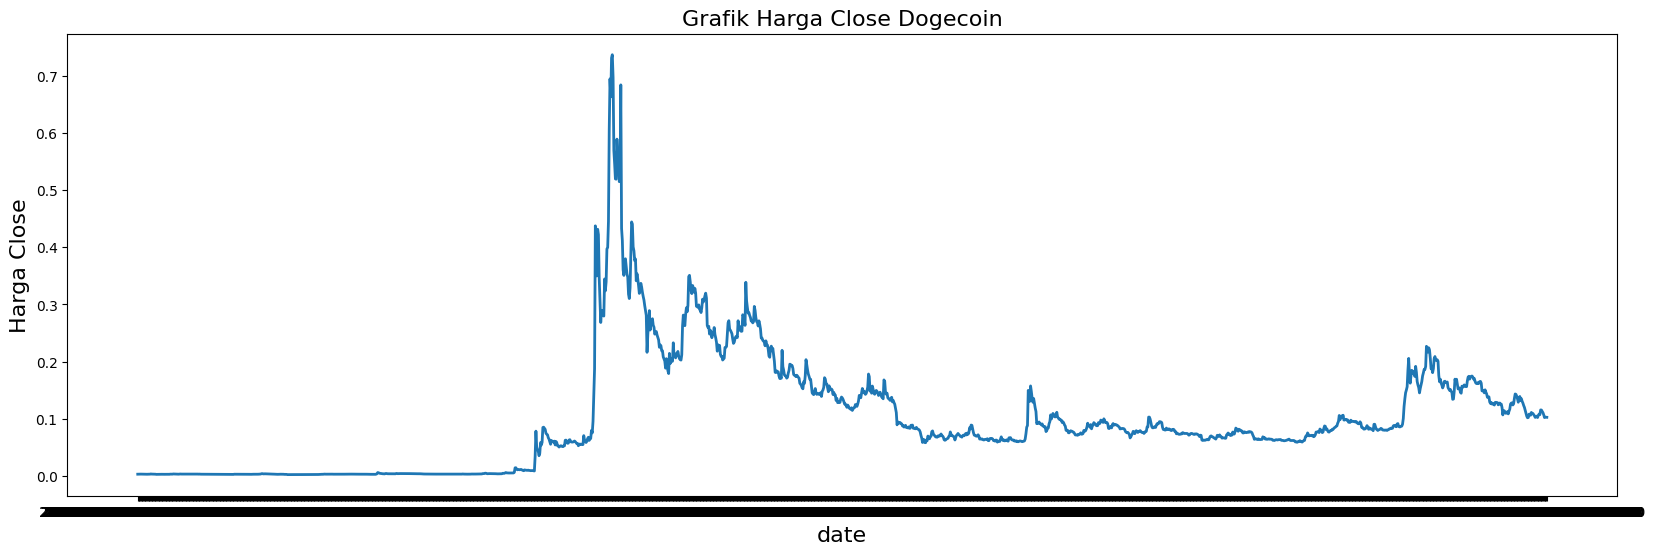

In [3]:
#plotting data
plt.figure(figsize=(20,6))
plt.plot(data["Date"], data['Close'], lw=2)
plt.xlabel("date")
plt.xlabel("date", fontsize=16)
plt.ylabel("Harga Close", fontsize=16)
plt.title("Grafik Harga Close Dogecoin", fontsize=16);

data yang saya dapatkan merupakan tipe data yang non-linear

##Praproses Data


##Menghapus kolom yang tidak digunakan
Disini saya menghapus kolom price dan volume karena Kolom Price dapat dianggap redundan sedangkan untuk volume dihapus karena hanya berisi data kosong

In [4]:
# Menghapus kolom 'Volume' secara permanen
data = data.drop(columns=['Price','Volume'])
print(data.head())

                        Date  Adj Close     Close      High       Low  \
0  2019-09-01 00:00:00+00:00   0.002492  0.002533  0.002443  0.002512   
1  2019-09-02 00:00:00+00:00   0.002596  0.002616  0.002462  0.002492   
2  2019-09-03 00:00:00+00:00   0.002595  0.002724  0.002560  0.002598   
3  2019-09-04 00:00:00+00:00   0.002690  0.002695  0.002541  0.002596   
4  2019-09-05 00:00:00+00:00   0.002531  0.002692  0.002505  0.002690   

       Open  
0  22742519  
1  25999239  
2  40548612  
3  27623103  
4  32285101  


###Mengecek Data Duplikat
Mengecek data duplikat adalah langkah pertama yang penting untuk memastikan tidak ada baris yang terulang dalam dataset. Data duplikat dapat menyebabkan model belajar dari data yang sama lebih dari sekali, yang bisa menurunkan performa model. Anda dapat menggunakan fungsi seperti duplicated() atau drop_duplicates() pada DataFrame untuk menemukan dan menghapus duplikat.

In [5]:
# Mengecek apakah ada data yang sama
print(data.duplicated().sum())

0


###Mengecek Data Hilang
Data hilang (missing values) bisa memengaruhi akurasi model. Sebelum melanjutkan ke langkah pemodelan, sangat penting untuk memeriksa apakah ada nilai yang hilang dalam dataset dan menangani mereka dengan cara yang sesuai. Misalnya, Anda dapat mengisi nilai yang hilang dengan nilai rata-rata, median, atau mode, atau bahkan menghapus baris yang mengandung data hilang jika jumlahnya sedikit.



In [6]:
# Mengecek apakah ada nilai yang hilang (missing values)
print(data.isnull().sum())

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
dtype: int64


###Mengubah kolom date menjadi indeks
Untuk analisis time series, sangat penting untuk menjadikan kolom Date sebagai indeks DataFrame. Ini memungkinkan kita untuk melakukan manipulasi data berbasis waktu, seperti resampling, rolling window, atau analisis musiman.

In [7]:
# Mengubah kolom Date menjadi indeks
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Menampilkan 5 baris pertama
print(data.head())

                           Adj Close     Close      High       Low      Open
Date                                                                        
2019-09-01 00:00:00+00:00   0.002492  0.002533  0.002443  0.002512  22742519
2019-09-02 00:00:00+00:00   0.002596  0.002616  0.002462  0.002492  25999239
2019-09-03 00:00:00+00:00   0.002595  0.002724  0.002560  0.002598  40548612
2019-09-04 00:00:00+00:00   0.002690  0.002695  0.002541  0.002596  27623103
2019-09-05 00:00:00+00:00   0.002531  0.002692  0.002505  0.002690  32285101


###Menampilkan Korelasi
Menampilkan korelasi antar variabel dalam dataset sangat penting untuk memahami hubungan antara fitur. Korelasi yang tinggi antar fitur bisa menunjukkan bahwa beberapa fitur redundant, yang bisa menyebabkan masalah multikolinearitas dalam model prediksi. Dengan menggunakan matriks korelasi kita dapat melihat hubungan antar fitur numerik dalam dataset.

In [8]:
# Menghitung korelasi hanya untuk kolom numerik
print(data.corr())

           Adj Close     Close      High       Low      Open
Adj Close   1.000000  0.994017  0.993279  0.990671  0.561773
Close       0.994017  1.000000  0.983487  0.992463  0.597608
High        0.993279  0.983487  1.000000  0.992223  0.483750
Low         0.990671  0.992463  0.992223  1.000000  0.524181
Open        0.561773  0.597608  0.483750  0.524181  1.000000


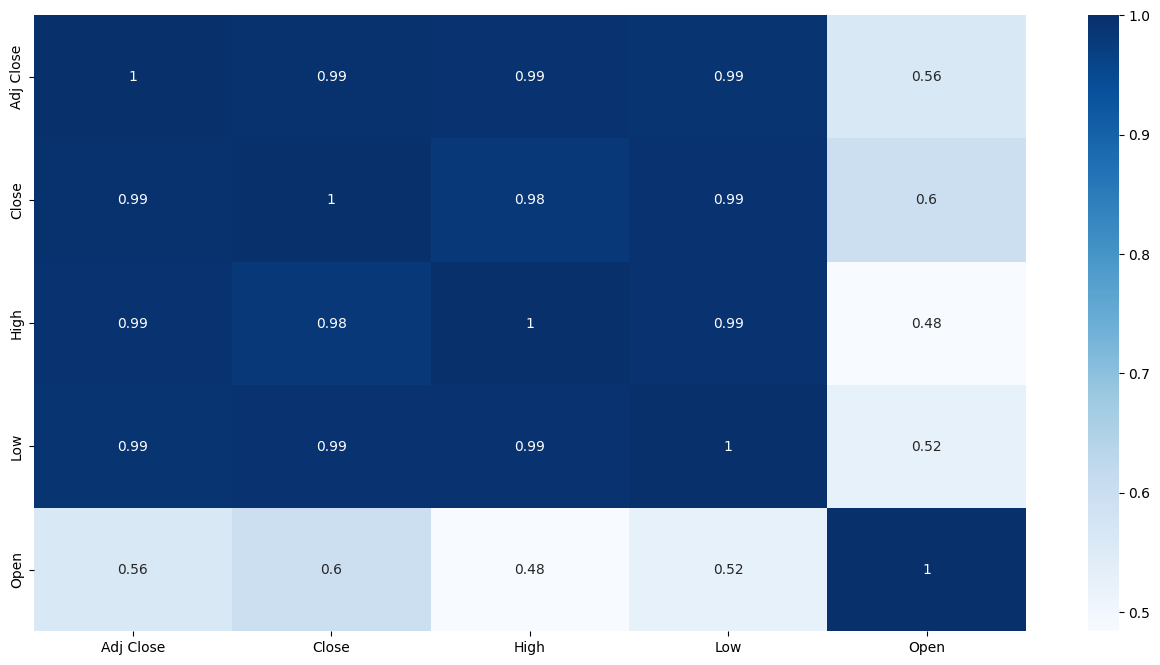

In [9]:
#heat map of all variable
plt.figure(figsize=(16,8))
sns.heatmap(data.corr(), cmap="Blues", annot=True)
plt.show()

###Mengecek Outlier
Outlier (pencilan) adalah nilai yang jauh berbeda dari nilai lainnya dalam dataset. Outlier dapat mempengaruhi model prediksi, terutama jika model sangat sensitif terhadap nilai ekstrem. Oleh karena itu, penting untuk mendeteksi outlier, baik menggunakan teknik statistik seperti IQR (Interquartile Range) atau visualisasi seperti box plot.

Disini saya menggunakan IQR, Interquartile Range (IQR) adalah ukuran statistik yang digunakan untuk menggambarkan rentang nilai tengah dari dataset dan membantu dalam mendeteksi outlier. IQR dihitung sebagai selisih antara Kuartil Ketiga (Q3) dan Kuartil Pertama (Q1), yaitu:

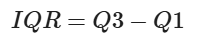

Kuartil:
* Kuartil pertama (Q1) adalah nilai yang membagi 25% data terendah. Ini adalah nilai pada posisi ke-25% dalam urutan data yang terurut.
* Kuartil ketiga (Q3) adalah nilai yang membagi 25% data tertinggi. Ini adalah nilai pada posisi ke-75% dalam urutan data yang terurut.
* Median (Q2) adalah nilai yang membagi dataset menjadi dua bagian yang sama (50%).

Fungsi IQR :

IQR menggambarkan seberapa tersebar data dalam kuartil tengah, yaitu 50% data yang terletak di antara Q1 dan Q3. Karena IQR mengabaikan nilai ekstrim (outlier), maka IQR sangat berguna untuk mendeteksi dan mengatasi outlier dalam dataset yang terdistribusi tidak normal atau memiliki data ekstrim.

Jumlah outlier berdasarkan IQR: 47
Outliers berdasarkan IQR:
                            Adj Close     Close      High       Low  \
Date                                                                 
2021-04-16 00:00:00+00:00   0.365870  0.437700  0.180488  0.181587   
2021-04-17 00:00:00+00:00   0.284173  0.374455  0.236524  0.366098   
2021-04-18 00:00:00+00:00   0.320475  0.349918  0.246440  0.285105   
2021-04-19 00:00:00+00:00   0.407318  0.431751  0.309080  0.320466   
2021-04-20 00:00:00+00:00   0.319500  0.422347  0.271618  0.408435   
2021-04-21 00:00:00+00:00   0.306925  0.346966  0.297036  0.316953   
2021-04-28 00:00:00+00:00   0.323682  0.344662  0.256231  0.272273   
2021-05-01 00:00:00+00:00   0.392987  0.397135  0.328290  0.337559   
2021-05-02 00:00:00+00:00   0.376046  0.400029  0.364874  0.391087   
2021-05-03 00:00:00+00:00   0.441707  0.445567  0.373631  0.373631   
2021-05-04 00:00:00+00:00   0.541334  0.605998  0.400800  0.440274   
2021-05-05 00:00:00+00:00   

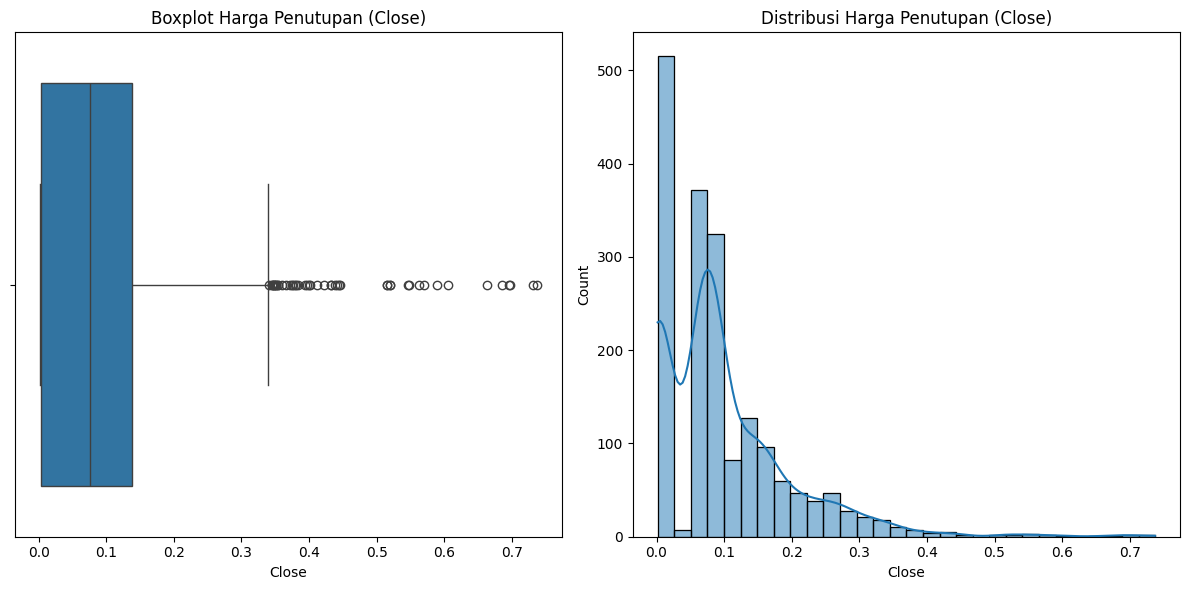

In [10]:
# Menghitung IQR untuk mendeteksi outlier
Q1 = data["Close"].quantile(0.25)
Q3 = data["Close"].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi outlier
outliers_iqr = data[(data["Close"] < lower_bound) | (data["Close"] > upper_bound)]
print("Jumlah outlier berdasarkan IQR:", len(outliers_iqr))
print("Outliers berdasarkan IQR:\n", outliers_iqr)

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Boxplot untuk mendeteksi outlier berdasarkan IQR
plt.figure(figsize=(12, 6))

# Boxplot untuk harga penutupan (Close)
plt.subplot(1, 2, 1)
sns.boxplot(x=data["Close"])
plt.title("Boxplot Harga Penutupan (Close)")

# Histogram untuk melihat distribusi harga penutupan (Close)
plt.subplot(1, 2, 2)
sns.histplot(data["Close"], bins=30, kde=True)
plt.title("Distribusi Harga Penutupan (Close)")

plt.tight_layout()
plt.show()

###Menghapus Outlier
Setelah mendeteksi outlier, diputuskan untuk menghapusnya karena dianggap tidak relevan atau bisa mengganggu analisis.


In [11]:
# Menghapus outlier berdasarkan IQR
cleaned_data_iqr = data[(data["Close"] >= lower_bound) & (data["Close"] <= upper_bound)]

# Mengecek jumlah data setelah pembersihan
print("Jumlah data setelah penghapusan outlier berdasarkan IQR:", len(cleaned_data_iqr))
outliers_iqr = cleaned_data_iqr[(cleaned_data_iqr["Close"] < lower_bound) | (cleaned_data_iqr["Close"] > upper_bound)]
print("Jumlah outlier berdasarkan IQR:", len(outliers_iqr))
print("Outliers berdasarkan IQR:\n", outliers_iqr)

Jumlah data setelah penghapusan outlier berdasarkan IQR: 1780
Jumlah outlier berdasarkan IQR: 0
Outliers berdasarkan IQR:
 Empty DataFrame
Columns: [Adj Close, Close, High, Low, Open]
Index: []


###Normalisasi Data
Normalisasi data diperlukan untuk skala yang konsisten di antara fitur-fitur yang berbeda.

Disini saya menggunakan MinMaxScaler, MinMaxScaler adalah salah satu metode normalisasi yang mengubah skala data agar berada dalam rentang tertentu, biasanya antara 0 dan 1.

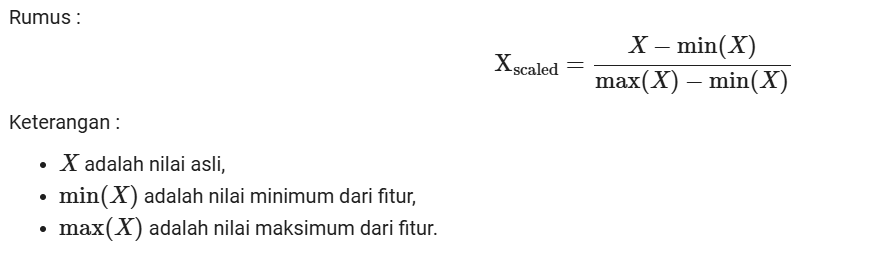

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Normalisasi menggunakan MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(cleaned_data_iqr[["Close", "High", "Low", "Open", "Adj Close"]])

# Mengonversi kembali hasil scaling menjadi DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=["Close", "High", "Low", "Open", "Adj Close"])

# Menampilkan hasil scaling
print(scaled_data.head())

      Close      High       Low      Open  Adj Close
0  0.002724  0.003751  0.002983  0.000000   0.002842
1  0.002969  0.003811  0.002922  0.000128   0.003152
2  0.003289  0.004118  0.003247  0.000702   0.003149
3  0.003203  0.004058  0.003241  0.000192   0.003431
4  0.003194  0.003946  0.003529  0.000376   0.002958


###Membagi Data Menjadi training dan testing
Pembagian dataset menjadi data pelatihan (training) dan pengujian (testing) adalah langkah penting untuk menghindari overfitting dan memastikan model dapat dievaluasi dengan baik pada data yang belum pernah dilihat sebelumnya.
Dalam analisis kali ini, saya membaginya menjadi 80% untuk pelatihan dan 20% untuk pengujian.

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fungsi untuk menghitung MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Fungsi untuk membuat target yang digeser (y_t+1, y_t+2, dst.)
def create_shifted_targets(data, steps):
    targets = []
    for step in range(1, steps + 1):
        targets.append(data.shift(-step))  # Geser data untuk langkah ke depan
    return pd.concat(targets, axis=1)

# Memisahkan fitur (X) dan target (y)
X = scaled_data[["High", "Low", "Open", "Adj Close"]]  # Fitur
y = scaled_data["Close"]  # Target (Harga Close)

# Membuat target yang digeser untuk multi-step forecasting (misalnya t+1, t+2)
steps = 2  # Prediksi untuk t+1, t+2
y_multi = create_shifted_targets(y, steps)

# Menghapus baris yang mengandung NaN dari target yang digeser
y_multi = y_multi.dropna()

# Menyelaraskan data X dengan y_multi setelah penghapusan NaN
X = X.loc[y_multi.index]  # Menyelaraskan indeks X dengan y_multi

# Membagi data menjadi 80% untuk training dan 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y_multi, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1422, 4)
Test set: (356, 4)


##Pemodelan Data
Disini saya menggunakan 3 model yaitu Regresi linear, RandomForestRegressor, dan SVR. Berikut penjelasannya :
* Regresi Linear adalah metode statistik yang digunakan untuk memodelkan hubungan antara satu atau lebih fitur independen (variabel input) dan variabel dependen (variabel output). Pada regresi linier, hubungan antara variabel-variabel tersebut diasumsikan linier, artinya perubahan pada variabel input menghasilkan perubahan proporsional pada variabel output.
* Random Forest adalah model ensemble yang menggunakan banyak pohon keputusan untuk melakukan prediksi. Setiap pohon dalam hutan (forest) dibuat dengan memilih subset acak dari fitur dan data training yang berbeda. Prediksi dari setiap pohon kemudian digabungkan untuk memberikan prediksi akhir.
* Support Vector Regression (SVR) adalah algoritma regresi yang menggunakan prinsip-prinsip Support Vector Machine (SVM) untuk regresi. SVR berusaha menemukan garis atau hyperplane yang memiliki margin yang lebih kecil di sekitar data, dengan tujuan meminimalkan kesalahan prediksi.


Untuk step nya saya hanya menggunakan 2 steps karena membatasi prediksi hanya pada 2 langkah (t+1 dan t+2) adalah keputusan yang masuk akal dalam konteks pasar cryptocurrency yang sangat volatile dan tidak pasti. Prediksi jangka panjang dalam konteks ini memiliki risiko yang lebih besar untuk menghasilkan kesalahan yang akumulatif dan cenderung kurang relevan secara praktis. Dua langkah ini memberikan keseimbangan yang baik antara akurasi, relevansi, dan kerumitan model. Dalam prakteknya, trader atau investor lebih sering memanfaatkan prediksi harga untuk waktu dekat (seperti satu atau dua hari ke depan) untuk membuat keputusan perdagangan atau investasi yang cepat dan berbasis data yang lebih kuat.

Dan berikut adalah hasil modelnya :

###Regresi Linear

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Menyiapkan list untuk menyimpan evaluasi total (MAE, RMSE, R2, MAPE) untuk semua langkah
mae_list, rmse_list, r2_list, mape_list = [], [], [], []

# Model untuk prediksi multi-step
y_pred_list = []
for step in range(steps):
    # Melatih model regresi untuk setiap langkah ke depan (t+1, t+2)
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train.iloc[:, step])  # Latih model untuk langkah ke-step

    # Prediksi harga untuk langkah ke depan
    y_pred = lr_model.predict(X_test)
    y_pred_list.append(y_pred)

    # Evaluasi model untuk langkah ini
    mae = mean_absolute_error(y_test.iloc[:, step], y_pred)

    # Menghitung RMSE
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, step], y_pred))

    r2 = r2_score(y_test.iloc[:, step], y_pred)
    mape = mean_absolute_percentage_error(y_test.iloc[:, step], y_pred)

    # Menyimpan hasil evaluasi setiap langkah
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)
    mape_list.append(mape)

# Menampilkan hasil evaluasi setelah semua langkah selesai
print("\nHasil Evaluasi untuk 2 Langkah Prediksi:")
print(f"Rata-rata MAE: {np.mean(mae_list):.4f}")
print(f"Rata-rata RMSE: {np.mean(rmse_list):.4f}")
print(f"Rata-rata R2: {np.mean(r2_list):.4f}")
print(f"Rata-rata MAPE: {np.mean(mape_list):.2f}%")


Hasil Evaluasi untuk 2 Langkah Prediksi:
Rata-rata MAE: 0.0122
Rata-rata RMSE: 0.0299
Rata-rata R2: 0.9798
Rata-rata MAPE: 10.39%


###Random Forest

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menyiapkan list untuk menyimpan evaluasi total (MAE, RMSE, R2, MAPE) untuk semua langkah
mae_list, rmse_list, r2_list, mape_list = [], [], [], []

# Model untuk prediksi multi-step
y_pred_list = []
for step in range(steps):
    # Melatih model Random Forest untuk setiap langkah ke depan
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Sesuaikan n_estimators sesuai kebutuhan
    rf_model.fit(X_train, y_train.iloc[:, step])  # Latih model untuk langkah ke-step

    # Prediksi harga untuk langkah ke depan
    y_pred_rf = rf_model.predict(X_test)
    y_pred_list.append(y_pred_rf)

    # Evaluasi model untuk langkah ini
    mae = mean_absolute_error(y_test.iloc[:, step], y_pred_rf)

    # Menghitung RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, step], y_pred_rf))

    r2 = r2_score(y_test.iloc[:, step], y_pred_rf)
    mape = mean_absolute_percentage_error(y_test.iloc[:, step], y_pred_rf)

    # Menyimpan hasil evaluasi setiap langkah
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)
    mape_list.append(mape)

# Menampilkan hasil evaluasi setelah semua langkah selesai
print("\nHasil Evaluasi untuk 2 Langkah Prediksi:")
print(f"Rata-rata MAE: {np.mean(mae_list):.4f}")
print(f"Rata-rata RMSE: {np.mean(rmse_list):.4f}")
print(f"Rata-rata R2: {np.mean(r2_list):.4f}")
print(f"Rata-rata MAPE: {np.mean(mape_list):.2f}%")



Hasil Evaluasi untuk 2 Langkah Prediksi:
Rata-rata MAE: 0.0127
Rata-rata RMSE: 0.0307
Rata-rata R2: 0.9788
Rata-rata MAPE: 5.99%


###Support Vector Regression (SVR)

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menyiapkan list untuk menyimpan evaluasi total (MAE, RMSE, R2, MAPE) untuk semua langkah
mae_list, rmse_list, r2_list, mape_list = [], [], [], []

# Model untuk prediksi multi-step menggunakan SVR
y_pred_list = []
for step in range(steps):
    # Melatih model SVR untuk setiap langkah ke depan
    svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)  # Sesuaikan parameter C dan epsilon jika perlu
    svr_model.fit(X_train, y_train.iloc[:, step])  # Latih model untuk langkah ke-step

    # Prediksi harga untuk langkah ke depan
    y_pred_svr = svr_model.predict(X_test)
    y_pred_list.append(y_pred_svr)

    # Evaluasi model untuk langkah ini
    mae = mean_absolute_error(y_test.iloc[:, step], y_pred_svr)

    # Menghitung RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, step], y_pred_svr))

    r2 = r2_score(y_test.iloc[:, step], y_pred_svr)
    mape = mean_absolute_percentage_error(y_test.iloc[:, step], y_pred_svr)

    # Menyimpan hasil evaluasi setiap langkah
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)
    mape_list.append(mape)

# Menampilkan hasil evaluasi setelah semua langkah selesai
print("\nHasil Evaluasi untuk 2 Langkah Prediksi:")
print(f"Rata-rata MAE: {np.mean(mae_list):.4f}")
print(f"Rata-rata RMSE: {np.mean(rmse_list):.4f}")
print(f"Rata-rata R2: {np.mean(r2_list):.4f}")
print(f"Rata-rata MAPE: {np.mean(mape_list):.2f}%")



Hasil Evaluasi untuk 2 Langkah Prediksi:
Rata-rata MAE: 0.0597
Rata-rata RMSE: 0.0722
Rata-rata R2: 0.8894
Rata-rata MAPE: 615.41%


#Evaluasi

Disini saya menggunakan 4 evaluasi yaitu : MAE, RMSE, R2 dan MAPE. Berikut adalah penjelasan lebih lengkapnya

##1. Mean Absolute Error (MAE)
Definisi: MAE mengukur rata-rata dari selisih absolut antara nilai prediksi dan nilai aktual. Ini memberikan gambaran seberapa besar rata-rata kesalahan dalam prediksi model tanpa mempertimbangkan arah kesalahan (apakah prediksi lebih tinggi atau lebih rendah dari nilai aktual).







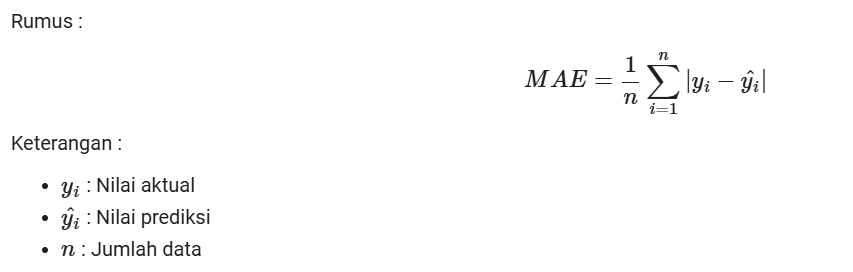

MAE memberikan nilai kesalahan yang mudah dipahami dan digunakan ketika kita ingin mengetahui rata-rata seberapa besar kesalahan dalam prediksi, tanpa terlalu memikirkan apakah prediksi tersebut lebih besar atau lebih kecil dari nilai yang sebenarnya.

##2. RMSE (Root Mean Squared Error)
Definisi: RMSE adalah akar kuadrat dari rata-rata kuadrat selisih antara nilai prediksi dan nilai aktual. RMSE memberi lebih banyak penalti pada kesalahan besar, mirip dengan MSE, tetapi karena diambil akar kuadratnya, RMSE akan berada dalam satuan yang sama dengan data, sehingga lebih mudah dipahami.

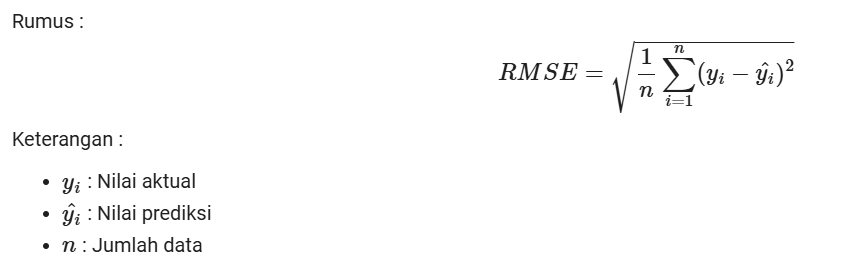

RMSE memberikan penalti yang lebih besar pada kesalahan besar dan sangat sensitif terhadap outlier. Nilai RMSE yang lebih kecil menunjukkan prediksi yang lebih akurat.

##3. R-squared (R²)
Definisi: R² adalah ukuran seberapa baik model dalam menjelaskan variasi dalam data yang diamati. Ini menunjukkan persentase varians dalam data yang dapat dijelaskan oleh model. R² juga dikenal sebagai koefisien determinasi.

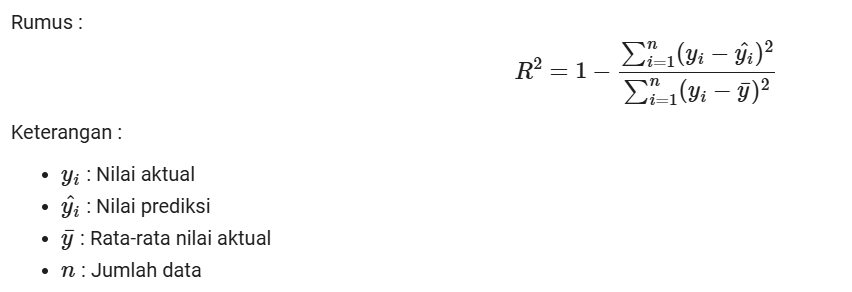

Nilai R² berkisar antara 0 dan 1, dengan 1 menunjukkan bahwa model dapat menjelaskan seluruh variasi dalam data, dan 0 menunjukkan bahwa model tidak dapat menjelaskan variasi lebih baik daripada model rata-rata. R² yang lebih tinggi menunjukkan bahwa model lebih baik dalam menangkap pola dalam data.

##4. Mean Absolute Percentage Error (MAPE)
Definisi: MAPE mengukur kesalahan rata-rata dalam bentuk persentase antara nilai prediksi dan nilai aktual. Ini memberikan gambaran tentang akurasi prediksi dalam persentase, yang memudahkan interpretasi bagi pengguna yang tidak terbiasa dengan unit atau skala data.

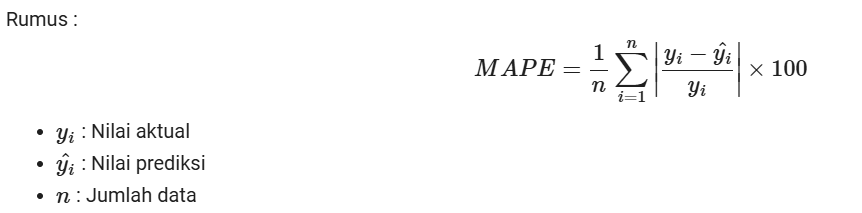

MAPE memberikan persentase kesalahan rata-rata dalam prediksi. Nilai MAPE yang lebih rendah menunjukkan model yang lebih akurat. Nilai MAPE yang tinggi menunjukkan bahwa model sering membuat kesalahan besar.

##Hasil Yang Didapatkan
setelah melakukan pemodelan data menggunakan beberapa algoritma, dilakukan evaluasi terhadap model yang telah dilatih untuk memprediksi harga Dogecoin dengan pendekatan multi-step forecasting (2 langkah ke depan, yaitu t+1 dan t+2). Model yang digunakan terdiri dari Regresi Linier, Random Forest Regressor, dan Support Vector Regression (SVR). Berdasarkan hasil evaluasi, model terbaik yang memberikan performa paling optimal adalah Random Forest Regressor.

Hasil Evaluasi untuk 2 Langkah Prediksi menggunakan Random Forest Regressor:
* Rata-rata MAE (Mean Absolute Error): 0.0127,
MAE yang rendah menunjukkan bahwa kesalahan rata-rata antara harga aktual dan prediksi sangat kecil, yang menandakan akurasi prediksi yang cukup baik.

* Rata-rata RMSE (Root Mean Squared Error): 0.0307,
Nilai MSE yang rendah mengindikasikan bahwa kesalahan kuadrat rata-rata juga kecil, menunjukkan bahwa prediksi model sangat mendekati nilai aktual, dengan penalti yang relatif kecil untuk kesalahan besar.

* Rata-rata R² (R-squared): 0.9788,
Nilai R² yang tinggi (hampir 1) menunjukkan bahwa model dapat menjelaskan lebih dari 95% variasi dalam data, yang menandakan bahwa model sangat baik dalam menangkap pola dalam data.

* Rata-rata MAPE (Mean Absolute Percentage Error): 5.99%,
Nilai MAPE yang rendah menunjukkan bahwa rata-rata kesalahan prediksi dalam bentuk persentase adalah 5.99%, yang tergolong cukup akurat, mengingat prediksi untuk harga cryptocurrency dapat sangat volatile.

##Visualisasi Hasil Dari Model Random Forest Regressor

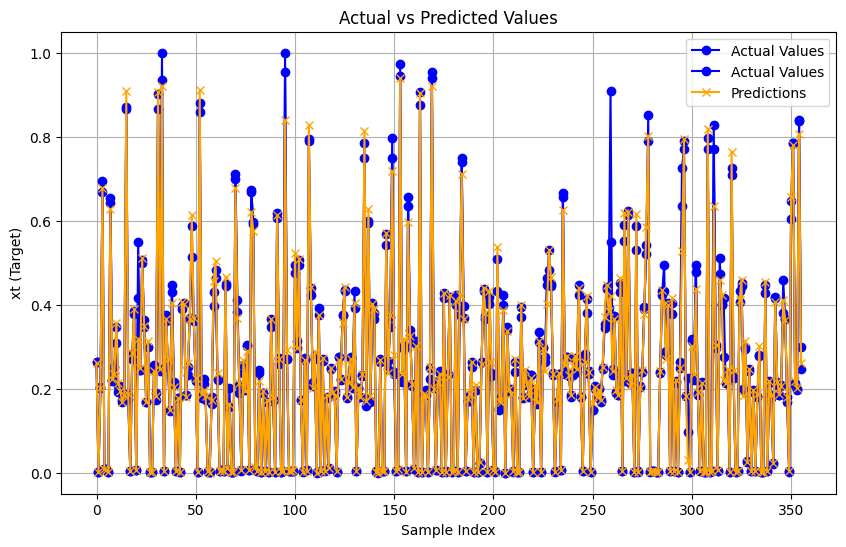

In [17]:
# Visualizing Actual vs Predicted Values
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(range(len(y_test)), y_test, label='Actual Values', color='blue', marker='o')

# Plot predictions
plt.plot(range(len(y_test)), y_pred_rf, label='Predictions', color='orange', marker='x')

# Adding labels and title
plt.xlabel('Sample Index')
plt.ylabel('xt (Target)')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

#Dampak Hasil Analisis

Berdasarkan hasil evaluasi model untuk memprediksi harga Dogecoin menggunakan tiga algoritma Regresi Linier, Random Forest Regressor, dan Support Vector Regression (SVR) terdapat beberapa temuan penting yang dapat memberikan wawasan terhadap akurasi prediksi dan potensi penggunaan model tersebut dalam konteks pasar cryptocurrency. Berikut adalah beberapa dampak yang dapat ditarik dari hasil analisis ini:

##1. Akurasinya Tinggi (R²: 0.9788)

* Nilai R² sebesar 0.9788 menunjukkan bahwa model Random Forest Regressor dapat menjelaskan hampir 98% variasi dalam harga Dogecoin. Ini berarti model sangat efektif dalam memprediksi harga berdasarkan fitur yang digunakan, seperti harga tertinggi, terendah, buka, dan tutup sebelumnya. Dalam konteks trading atau investasi, prediksi dengan R² yang tinggi dapat memberikan kepercayaan lebih dalam pengambilan keputusan berbasis data.

##2. Kesalahan Prediksi yang Minim (MAE : 0.0127, MAPE : 5.99%)
* Dengan nilai MAE yang rendah (0.0127) dan MAPE yang mencapai hanya 5.99%, model menunjukkan bahwa rata-rata kesalahan prediksi sangat kecil. MAPE yang rendah ini menjadi indikator bahwa meskipun cryptocurrency seperti Dogecoin sangat volatile, model ini masih mampu menghasilkan prediksi yang cukup baik dan akurat.
* MAPE yang berada pada angka 5.99% mengindikasikan bahwa prediksi harga tidak akan terlalu jauh dari nilai aktual dalam jangka pendek (t+1 dan t+2). Hal ini sangat penting untuk trader yang mengandalkan prediksi harga dalam waktu dekat.

##3. Performa yang Stabil dengan Penalti Kecil untuk Kesalahan Besar (RMSE: 0.0307)
* Nilai RMSE yang rendah (0.0307) mengindikasikan bahwa model ini tidak hanya memberikan prediksi yang akurat, tetapi juga meminimalkan penalti terhadap kesalahan besar. Dalam pasar cryptocurrency yang cenderung berfluktuasi, kemampuan untuk menghindari kesalahan besar menjadi sangat penting karena dapat mengurangi risiko keputusan investasi yang merugikan.

#strategi Berdasarkan Hasil Analisis
Berdasarkan hasil analisis dan evaluasi prediksi harga Dogecoin, beberapa strategi berikut dapat digunakan untuk mengoptimalkan keputusan investasi dan perdagangan :
##1. Strategi Day Trading (Perdagangan Jangka Pendek)
Dengan memanfaatkan prediksi harga Dogecoin untuk t+1 dan t+2, investor atau trader dapat memanfaatkan pergerakan harga jangka pendek. Strategi ini mengandalkan fluktuasi harga yang sering terjadi dalam jangka waktu singkat.
##2. Strategi Hedging
Dengan volatilitas tinggi yang terjadi di pasar cryptocurrency, menggunakan strategi hedging menjadi penting untuk melindungi portofolio dari potensi kerugian besar. Jika prediksi menunjukkan kemungkinan penurunan harga yang signifikan, trader dapat mengurangi eksposur mereka terhadap Dogecoin atau menggunakan instrumen derivatif (seperti futures atau opsi) untuk lindung nilai.
##3. Strategi Portfolio Diversification
Untuk investor jangka panjang, hasil analisis ini dapat digunakan sebagai bagian dari strategi diversifikasi portofolio. Dengan mengetahui tren jangka pendek dalam harga Dogecoin, investor dapat lebih percaya diri dalam mengalokasikan sebagian kecil dari portofolio mereka untuk cryptocurrency sambil menjaga risiko yang lebih terdiversifikasi.